---
title: "Lecture 18: Adaptive and multistep methods"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture18_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
    html: 
        code-fold: true
        embed-resources: true
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
filters: 
  - input/remove-pause.lua
execute:
  echo: true
  eval: true
---

# Adaptive Runge-Kutta

In many problems, a fixed step size is far from the most efficient strategy.

## Step size prediction

Suppose that, starting from a given value $u_i$ and using a step size $h$, we run one step of two different RK methods simultaneously: one method with order $p$, producing $u_{i+1}$, and the other method with order $p+1$, producing $\tilde{u}_{i+1}$. 

. . .

We can expect that $\tilde{\mathbf{u}}_{i+1}$ is a much better approximation to the solution than $\mathbf{u}_{i+1}$ is. We can then estimate the actual local error made by the $p$th-order method as

$$E_i(h)=\|\tilde{\mathbf{u}}_{i+1} - \mathbf{u}_{i+1}\|.$$

. . .

What step size *should* we have taken to meet an error target of size $\epsilon$? 

* Given the LTE as $h\rightarrow 0$, we guess that $E_i(h)\approx C h^{p+1}$. 
* For step size $q h$ for some $q>0$, we expect 
$E_i(qh)\approx C q^{p+1}h^{p+1}.$
* Our best guess for $q$ would therefore be to set $E_i(qh)\approx \epsilon$, or
$$q \approx \left(\frac{\epsilon}{E_i(h)}\right)^{1/(p+1)}.$$


---

Another option is to aim to control the contribution to *global* error, which is closer to $E_i(qh)/(q h)$. Then we end up with
$$q \le \left(\frac{\epsilon}{E_i(h)}\right)^{1/p}.$$

. . .

Experts have different recommendations about which to use. Modern practice seems to favor the first choice for $q$.

. . .

::: {.callout-note icon=false}
## Definition: Adaptive step size for an IVP
Given a solution estimate $u_i$ at $t=t_i$, and a step size $h$, do the following:

1. Produce estimates ${u}_{i+1}$ and $\tilde{u}_{i+1}$, and estimate the error.
2. If the error is small enough, adopt $\tilde{u}_{i+1}$ as the solution value at $t=t_i+h$, then increment $i$.
3. Replace $h$ by $q h$, for $q$ defined by one of the rules above.
4. Repeat until $t=b$.
:::

[Note that we always scale $h$, but depending upon the outcome of the check in Step 2, the scaling parameter $q$ may be greater or less than 1.]{.content-hidden when-format='revealjs' when-format='pptx'} 

## Embedded formulas

Suppose, for example, we choose to use a  pair of second- and third-order RK methods to get the $\mathbf{u}_{i+1}$ and $\tilde{\mathbf{u}}_{i+1}$ needed in the algorithm above. 

. . .

Then we seem to need at least $2+3=5$ evaluations of $f(t,y)$ for each attempted time step. This is more than double the computational work needed by the second-order method without adaptivity. 

. . .

Fortunately, this can be reduced by using **embedded Runge–Kutta** formulas, a pair of RK methods whose stages share the same internal $f$ evaluations. [These stages are combined differently in order to get estimates of two different orders of accuracy.]{.content-hidden when-format='revealjs' when-format='pptx'} 

---

A good example of an embedded method is the **Bogacki–Shampine** (BS23) formula, given by the table

$$\begin{array}{r|cccc}
0                  & \rule{0pt}{2.75ex} &                    &                    &                    \\
\frac{1}{2}        & \frac{1}{2}        & \rule{0pt}{2.75ex} &                    &                    \\
\frac{3}{4}        & 0                  & \frac{3}{4}        & \rule{0pt}{2.75ex} &                    \\
1                 & \frac{2}{9}        & \frac{1}{3}        & \frac{4}{9}        & \rule{0pt}{2.75ex} \\[2pt] \hline
\rule{0pt}{2.75ex} & \frac{2}{9}        & \frac{1}{3}        & \frac{4}{9}        & 0                  \\[2pt] \hline
\rule{0pt}{2.75ex} & \frac{7}{24}       & \frac{1}{4}        & \frac{1}{3}        & \frac{1}{8}
\end{array}$$

. . .

The top part of the table describes four stages in the usual RK fashion. The last two rows describe how to construct a third-order estimate $\tilde{\mathbf{u}}_{i+1}$ and a second-order estimate $\mathbf{u}_{i+1}$ by taking different combinations of those stages.

## Implementation

In [19]:
# | echo: false
using DifferentialEquations
using LinearAlgebra
using Plots
using Printf

In [2]:
"""
    rk23(ivp,tol)

Apply an adaptive embedded RK formula pair to solve given IVP with
estimated error `tol`. Returns a vector of times and a vector of
solution values.
"""
function rk23(ivp,tol)
    # Initialize for the first time step.
    a,b = ivp.tspan
    t = [a]
    u = [float(ivp.u0)];   i = 1;
    h = 0.5*tol^(1/3)
    s₁ = ivp.f(ivp.u0,ivp.p,a)

    # Time stepping.
    while t[i] < b
        # Detect underflow of the step size.
        if t[i]+h == t[i]
            @warn "Stepsize too small near t=$(t[i])"
            break  # quit time stepping loop
        end

        # New RK stages.
        s₂ = ivp.f( u[i]+(h/2)*s₁,   ivp.p, t[i]+h/2   )
        s₃ = ivp.f( u[i]+(3h/4)*s₂, ivp.p, t[i]+3h/4 )
        unew2 = u[i] + h*(2s₁  + 3s₂ + 4s₃)/9   # 2rd order solution
        s₄ = ivp.f( unew2, ivp.p, t[i]+h )
        err = h*(-5s₁/72 + s₂/12 + s₃/9 - s₄/8)  # 2nd/3rd difference
        E = norm(err,Inf)                         # error estimate
        maxerr = tol*(1 + norm(u[i],Inf))     # relative/absolute blend

        # Accept the proposed step?
        if E < maxerr     # yes
            push!(t,t[i]+h)
            push!(u,unew2)
            i += 1
            s₁ = s₄       # use FSAL property
        end

        # Adjust step size.
        q = 0.8*(maxerr/E)^(1/3)   # conservative optimal step factor
        q = min(q,4)               # limit stepsize growth
        h = min(q*h,b-t[i])        # don't step past the end
    end
    return t,u
end

rk23

---

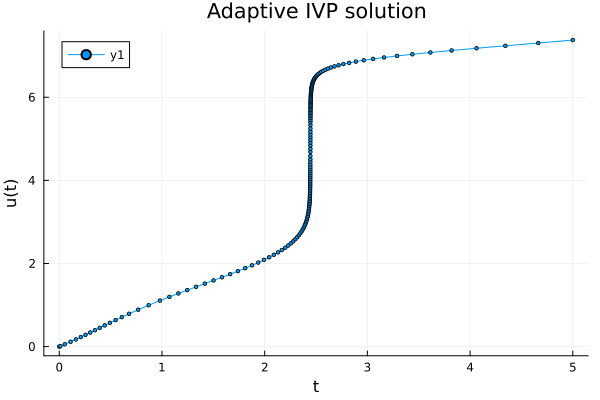

In [8]:
f = (u,p,t) -> exp(t-u*sin(u))
ivp = ODEProblem(f,0,(0.,5.))
t,u = rk23(ivp,1e-5)

plot(t,u,m=2,
    xlabel="t",ylabel="u(t)",title="Adaptive IVP solution")

---

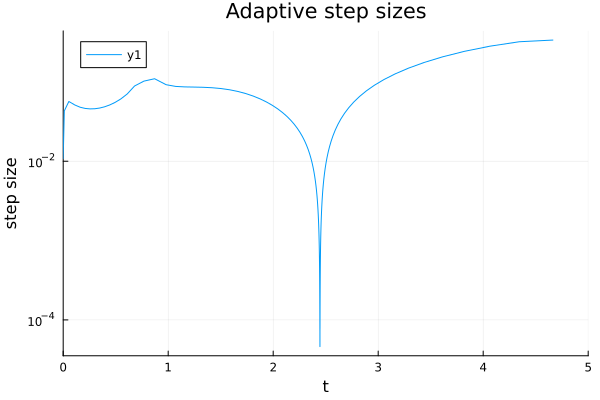

In [11]:
Δt = diff(t) # due to the solution's abrupt change, the step size shrinks correspondingly
plot(t[1:end-1],Δt,title="Adaptive step sizes",
    xaxis=("t",(0,5)),yaxis=(:log10,"step size"))

In [13]:
# uniform step size required to get this accuracy
println( "minimum step size = $(minimum(Δt))" ) 

minimum step size = 4.6096854609878335e-5


In [14]:
# average step size actually taken
println( "average step size = $(sum(Δt)/(length(t)-1))" )

average step size = 0.03205128205128205


. . .

We took fewer steps by a factor of almost 1000! [Even with the extra stage per step and the occasional rejected step, the savings are clear.]{.content-hidden when-format='revealjs' when-format='pptx'} 

---

Previously, we saw an IVP that appears to blow up in a finite amount of time. Because the solution increases so rapidly as it approaches the blowup, adaptive stepping is required to get close. 

In [16]:
f = (u,p,t) -> (t+u)^2
ivp = ODEProblem(f,1,(0.,1.))
t,u = rk23(ivp,1e-5);

┌ Warning: Stepsize too small near t=0.7854087204072808
└ @ Main /Users/jamiehaddock/Documents/GitHub/164-ScientificComputing/Lecture18/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W4sZmlsZQ==.jl:20


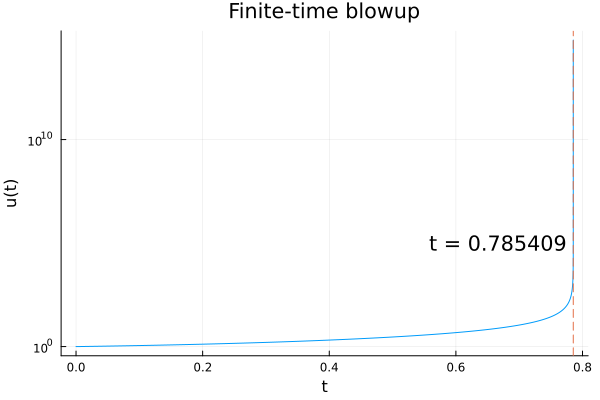

In [21]:
# the failure of the adaptivity gives a decent idea of when the singularity occurs
plot(t,u,legend=:none,
    xlabel="t",yaxis=(:log10,"u(t)"),title="Finite-time blowup")

tf = t[end]
vline!([tf],l=:dash)
annotate!(tf,1e5,@sprintf("t = %.6f ",tf),:right)

# Multistep methods

In Runge–Kutta methods we start at $u_i$ to find ${u}_{i+1}$, taking multiple $f$-evaluations (stages) to achieve high accuracy. 

. . .

In contrast, multistep methods boost accuracy by employing more of the history of the solution, taking information from the recent past. 

## Multistep methods

We denote $f_i = f(t_i,u_i).$

. . .

::: {.callout-note icon=false}
## Definition: Multistep method for IVPs
A $k$-step **multistep** (or *linear multistep*) method is given by the difference equation
\begin{align*}
u_{i+1} &= a_{k-1}u_i + \cdots + a_0 u_{i-k+1} \qquad \\ 
& \qquad + h ( b_kf_{i+1} + \cdots + b_0 f_{i-k+1}),
\end{align*}
where the $a_j$ and the $b_j$ are constants. If $b_k=0$, the method is **explicit**; otherwise, it is **implicit**.  
:::

. . .

We can use this method for iterations $i=k-1,\ldots,n-1$. 

. . .

We also need some way of generating the **starting values**
$$u_1=\alpha_1, \quad \ldots \quad u_{k-1}=\alpha_{k-1}.$$  These are often found with an RK formula.

. . .

If the method is explicit, $u_{i+1}$ is defined in terms of values at times $t_i$ and earlier, requiring only one new evaluation of $f$.

---

If the method is implicit, the unknown $u_{i+1}$ appears inside the function $f$ -- a nonlinear rootfinding problem for $u_{i+1}$ arises!  We'll see this next class.

. . .

As with RK formulas, a multistep method is entirely specified by the values of a few constants. The **Adams–Bashforth** (AB) methods are explicit, while **Adams–Moulton** (AM) and **backward differentiation formulas** (BD) are implicit. 

[The tables also list the methods' order of accuracy, to be defined shortly. We adopt the convention of referring to a multistep method by appending its order of accuracy to a two-letter name abbreviation, e.g., the AB3 method.]{.content-hidden when-format='revealjs' when-format='pptx'}  

---

Coefficients of Adams multistep formulas. All have $a_{k-1}=1$ and $a_{k-2} = \cdots = a_0 = 0$.

| name/order | steps $k$ |       $b_k$       |     $b_{k-1}$     |     $b_{k-2}$      |     $b_{k-3}$     |     $b_{k-4}$     |
|:----------:|:---------:|:-----------------:|:-----------------:|:------------------:|:-----------------:|:-----------------:|
|    AB1     |     1     |         0         |         1         |      (Euler)       |                   |                   |
|    AB2     |     2     |         0         |   $\frac{3}{2}$   |   $-\frac{1}{2}$   |                   |                   |
|    AB3     |     3     |         0         |  $\frac{23}{12}$  |  $-\frac{16}{12}$  |  $\frac{5}{12}$   |                   |
|    AB4     |     4     |         0         |  $\frac{55}{24}$  |  $-\frac{59}{24}$  |  $\frac{37}{24}$  |  $-\frac{9}{24}$  |
|    AM1     |     1     |         1         | (Backward Euler)  |                    |                   |                   |
|    AM2     |     1     |   $\frac{1}{2}$   |   $\frac{1}{2}$   |    (Trapezoid)     |                   |
|    AM3     |     2     |  $\frac{5}{12}$   |  $\frac{8}{12}$   |  $-\frac{1}{12}$   |                   |                   |
|    AM4     |     3     |  $\frac{9}{24}$   |  $\frac{19}{24}$  |  $-\frac{5}{24}$   |  $\frac{1}{24}$   |                   |
|    AM5     |     4     | $\frac{251}{720}$ | $\frac{646}{720}$ | $-\frac{264}{720}$ | $\frac{106}{720}$ | $-\frac{19}{720}$ |

---

Coefficients of backward differentiation formulas. All  have $b_k\neq 0$ and $b_{k-1} = \cdots = b_0 = 0$.

| name/order | steps $k$ | $a_{k-1}$       | $a_{k-2}$        | $a_{k-3}$       | $a_{k-4}$       | $b_k$           |
|:----------:|:---------:|:---------------:|:----------------:|:---------------:|:---------------:|:---------------:|
| BD1        | 1         | 1               | (Backward Euler) |                 |                 | 1               |
| BD2        | 2         | $\frac{4}{3}$   | $-\frac{1}{3}$   |                 |                 | $\frac{2}{3}$   |
| BD3        | 3         | $\frac{18}{11}$ | $-\frac{9}{11}$  | $\frac{2}{11}$  |                 | $\frac{6}{11}$  |
| BD4        | 4         | $\frac{48}{25}$ | $-\frac{36}{25}$ | $\frac{16}{25}$ | $-\frac{3}{25}$ | $\frac{12}{25}$ |

## Truncation and global error

The definition of local truncation error is easily extended to multistep methods. 

. . .

::: {.callout-note icon=false}
## Definition: LTE and order of accuracy for a multistep IVP method
For a multistep formula, the **local truncation error** is 
$$\tau_{i+1}(h) = \frac{\hat{u}(t_{i+1}) - a_{k-1}\hat{u}(t_i) - \cdots - a_0
    \hat{u}(t_{i-k+1})}{h} - \bigl[ b_kf(t_{i+1},\hat{u}(t_{i+1})) + \cdots +
  b_0f(t_{i-k+1},\hat{u}(t_{i-k+1})) \bigr].$$
If the local truncation error satisfies $\tau_{i+1}(h)=O(h^p)$, then $p$ is the **order of accuracy** of the formula. If $p>0$, the method is **consistent**.
:::

---

The first-order Adams–Moulton method is also known as **backward Euler**, because its difference equation is ${u}_{i+1} = u_i + hf_{i+1},$
which is equivalent to a backward-difference approximation to $u'(t_{i+1})$. 

. . .

To derive the LTE, we use the definition:

\begin{align*}
    h\tau_{i+1}(h) &= \hat{u}(t_{i+1}) - \hat{u}(t_i) - hf\bigl(t_{i+1},\hat{u}(t_{i+1})\bigr) \\
    &= \hat{u}(t_i) + h\hat{u}'(t_i) + \frac{h^2}{2}\hat{u}''(t_i) + O(h^3)
    - \hat{u}(t_i) -h \hat{u}'(t_{i+1}) \\
    &= h\hat{u}'(t_i) + \frac{h^2}{2}\hat{u}''(t_i) + O(h^3)
    - h[\hat{u}'(t_i) + h\hat{u}''(t_i) + O(h^2)]\\
    &= - \frac{h^2}{2}\hat{u}''(t_i) + O(h^3).
\end{align*}

. . .

Thus $\tau_{i+1}(h)=O(h)$ and AM1 (backward Euler) is a first-order method.

---

The AB2 method has the formula
${u}_{i+1} = u_i + h\left(\frac{3}{2} f_i - \frac{1}{2} f_{i-1} \right).$

. . .

We find that the method is second order from the LTE:

\begin{align*}
  h\tau_{i+1}(h)
  & = \hat{u}(t_{i+1}) - \hat{u}(t_i) - h\left[
    \frac{3}{2}f(t_i,\hat{u}(t_i)) - \frac{1}{2}f(t_{i-1},\hat{u}(t_{i-1}))
    \right]                                                                                   \\
  & = \hat{u}(t_i) + h\hat{u}'(t_i) + \frac{h^2}{2}\hat{u}''(t_i) + \frac{h^3}{6}\hat{u}'''(t_i) + O(h^4) \\
  & \qquad - \hat{u}(t_i) - \frac{3h}{2}\hat{u}'(t_i)  \\
  &\qquad  + \frac{h}{2} \bigl[\hat{u}'(t_i) - h\hat{u}''(t_i) + \frac{h^2}{2}\hat{u}'''(t_i) + O(h^3)\bigr]        \\
  & = \frac{5h^3}{12}\hat{u}'''(t_i) + O(h^4),
\end{align*}

. . .

so that $\tau_{i+1}(h)=O(h^2)$.

---

::: {.callout-tip icon=false}
## Note: 
The global error of each method presented today converges at the same order as the local truncation error.
:::

<!--
[verbose test]{.content-hidden when-format="revealjs" when-format="pptx"}

::: {.callout-caution icon=false}
## Exercise: 

:::

<details><summary>Answer:</summary> </details>


::: {.callout-note icon=false}
## Definition: 
 
:::


::: {.callout-tip icon=false}
## Note: 
 
:::
-->